# Workflow: Benchmark your RL algorithm against a model checked ground truth

**What is the motivation?**

Say you are developing a novel RL algorithm (we are not, in this workflow), and want to figure out how well it performs.
Plus, you have an interesting model given as a prism file, or a stormpy MDP.

With `VeriGym`, you can easily load the MDP into an `ExplicitEnv`, and train on it with your custom RL algorithm.
Additionally, you can use our `stormpy` interfacing to easily model check and generate a ground-truth solution and policy.
Then, you can observe how close your algorithm gets to the theoretically optimal value, and how your algorithm's learned policy behaves to an optimal policy from `stormpy`.

**What do we show here?**
In this workflow, we benchmark a standard RL algorithm against model checked ground-truth results with the following steps:
1. We load a `stormpy` MDP into `VeriGym`.
2. We train the resulting `FrameworkExplicitEnv` using `stable_baselines3` implementation of `DQN`.
3. We model check the MDP in `stormpy`.
4. We compare the resulting learned and optimal rewards, and the learned and checked policies using our `PolicyClass` modules.


## Imports and helpers

In [1]:
# Imports
import stable_baselines3 as sb3
from gymnasium.wrappers import TimeLimit

# VeriGym
from verigym.environments.frameworkexplicitenv import FrameworkExplicitEnv
from verigym.frameworks.stormpy.stormpy_utils import load_stormpy_model
from verigym.supplements.modelchecking import get_policy_from_stormpy, check_policy_value_in_stormpy
from verigym.frameworks.stable_baselines3.policy import SB3Policy
from workflow_utils import train_with_sb3_dqn, plot_logged_data, run_eval_episodes, plot_compare_policy_eval

# Paths etc.
mdp_path = "workflow_compare_files/simple_fuel_taxi.prism"
outpath = "../examples/workflow_compare_files/"

## Actual workflow

We are using the **fuel-taxi MDP** as an example here.
Fuel taxi is a custom variant of the `gym` grid-world environment `Taxi` (see [here](https://gymnasium.farama.org/environments/toy_text/taxi/)), with the addition of a fuel tank.
The taxi has to pick up a passenger and drive it to the destination without running out of fuel.

For this task, we are interested in maximizing the reward before reaching a terminal state.

We start our worklow by loading the taxi-MDP into `stormpy`, and creating a `FrameworkExplicitEnv` from it.
(The `eval_env` is identical and used for the DRL training evaluation.)

We then train our DRL model using the `stable_baselines3` implementation of DQN. 
Since the model is quite small, training is very fast.

In [2]:
propertystr = 'Rmax=? [F "done"]'
mdp = load_stormpy_model(mdp_path, property_strs=propertystr)

In [3]:
env = FrameworkExplicitEnv.from_stormpy(mdp)
env = TimeLimit(env, max_episode_steps=10)
eval_env = FrameworkExplicitEnv.from_stormpy(mdp)
eval_env = TimeLimit(eval_env, max_episode_steps=10)

### Toggle here to view or hide the training output...

In [4]:
train_with_sb3_dqn(env, eval_env, outpath + "dqn_model/", n_steps=5000)

Output()

Eval num_timesteps=200, episode_reward=-5.00 +/- 0.00

Episode length: 6.00 +/- 0.00

New best mean reward!

Eval num_timesteps=400, episode_reward=-5.00 +/- 0.00

...

Episode length: 10.00 +/- 0.00

Eval num_timesteps=4800, episode_reward=3.00 +/- 0.00

Episode length: 10.00 +/- 0.00

Eval num_timesteps=5000, episode_reward=3.00 +/- 0.00

Episode length: 10.00 +/- 0.00

### Comparing the policies

We now load our trained DQN policy and look at the reward development during training.
We only trained for 5000 steps, but the reward seems to be increasing.

In [5]:
model = sb3.DQN.load(outpath + "dqn_model/dqn_model")

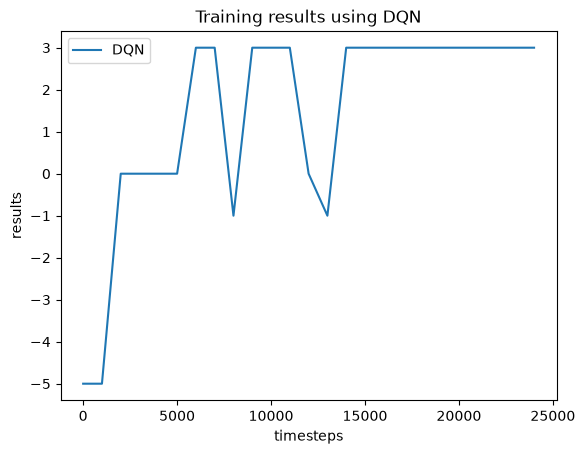

In [6]:
plot_logged_data([outpath + "dqn_model/log/evaluations.npz"], labels=["DQN"], key="results",
                 title="Training results using DQN",
                 eval_step=1000)

Now, we load our DRL-based policy as a `SB3Policy`, and additionally model check the MDP that underlies our environment using the reward-maximizing property. 
The model checked property is returned as a `StormpyPolicy` object.
Both policy classes can now be deployed on our environment.

In [7]:
sp_policy = get_policy_from_stormpy(env, propertystr)
rl_policy = SB3Policy(model)

For that, we collect some evaluation episodes using a utility function.

In [8]:
rl_eval = run_eval_episodes(env, rl_policy)
sp_eval = run_eval_episodes(env, sp_policy)

/Users/juleschmidt/Documents/VeriGym/examples/workflow_utils.py:125: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


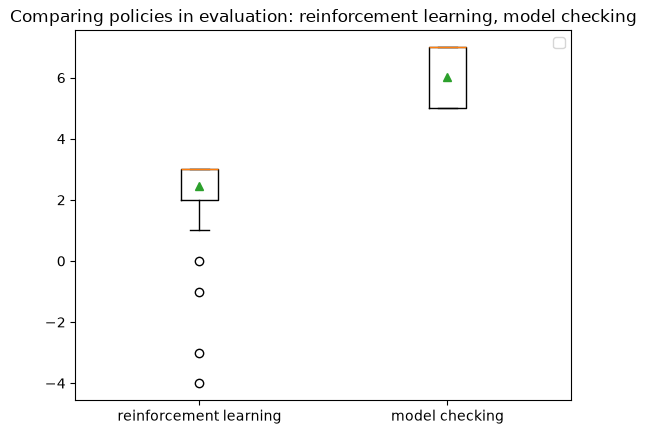

In [9]:
plot_compare_policy_eval([rl_eval, sp_eval], ["reinforcement learning", "model checking"])

We observe that the model checked policy performs much better than the RL trained policy. It looks like our view training steps were not sufficient yet, we should continue to search for better hyperparameters.

In addition to comparing the policies in evaluation, we can also model check our trained RL policy.
We can do that using a utility function in `VeriGym`. 
Under the hood, the following happens:
- We export the underlying MDP from our environment and combine it with the RL policy to build a Deterministic Markov Chain (DMTC).
- Then, we model check the DTMC in stormpy, and get a value vector with a value per state.

Finally, we can compare the value of that DTMC with the value in the original MDP.